In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import io
import requests

from src.nuclear_cost import PWR
from src.fuel_cycle import FuelCycle
from src.market import GasPlant

# Base Case

In [2]:
reactor = PWR()
fuel = FuelCycle()

print(f"Electrical power: {reactor.electrical_power_mw:,.0f} MWe")
print(f"Annual generation: {reactor.annual_generation_mwh / 1e6:.2f} TWh")
print()

requirements = fuel.enrichment_requirements(
    reactor.annual_fuel_requirement_kg
)
print(f"Annual fuel: {requirements['product_kg'] / 1e3:.2f} tHM")
print(f"Uranium feed: {requirements['feed_kgU'] / 1e3:.2f} tU")
print(f"SWU: {requirements['swu'] / 1e3:.1f} kSWU")
print()

costs = fuel.cost(
    reactor.annual_fuel_requirement_kg
)
for component, value in costs.items():
    print(f"{component.capitalize():12s}: ${value / 1e6:.2f}M")

fuel_cost_mwh = costs["total"] / reactor.annual_generation_mwh
print(f"\nFuel cost: ${fuel_cost_mwh:.2f}/MWh")

Electrical power: 1,122 MWe
Annual generation: 8.85 TWh

Annual fuel: 24.82 tHM
Uranium feed: 228.82 tU
SWU: 170.5 kSWU

Uranium     : $41.82M
Conversion  : $2.29M
Enrichment  : $25.58M
Fabrication : $7.45M
Total       : $77.14M

Fuel cost: $8.72/MWh


# Sensitivity Studies

## Fuel Cost MWh vs Uranium Price

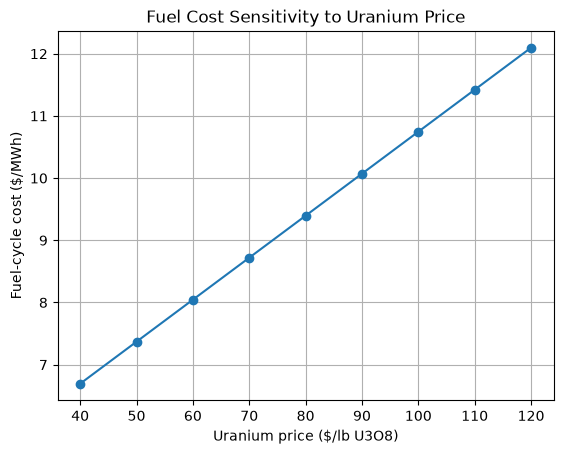

In [2]:
reactor = PWR()
uranium_prices = np.arange(40, 121, 10)

results = []
for price in uranium_prices:
    fuel = FuelCycle(uranium_price_lb=price)
    costs = fuel.cost(reactor.annual_fuel_requirement_kg)
    fuel_cost_mwh = costs["total"] / reactor.annual_generation_mwh
    results.append(fuel_cost_mwh)

plt.plot(uranium_prices, results, marker="o")
plt.xlabel("Uranium price ($/lb U3O8)")
plt.ylabel("Fuel-cycle cost ($/MWh)")
plt.title("Fuel Cost Sensitivity to Uranium Price")
plt.grid(True)
plt.show()

### Observations:

* Linear dependency of the fuel cost per MWh with the Uranium price
* This can seen in the equations directly:
    * $m \cdot x + b$
    * $x = P_U$, $m = F/E_{annual}$
* $m$ is called commodity exposure, it represents $\frac{\partial C_{fuel/MWh}}{\partial P_U}$

## Fuel Cost vs Uranium Price and SWU Price

$$
C_{fuel/MWh} = f(P_U, P_{SWU})
$$

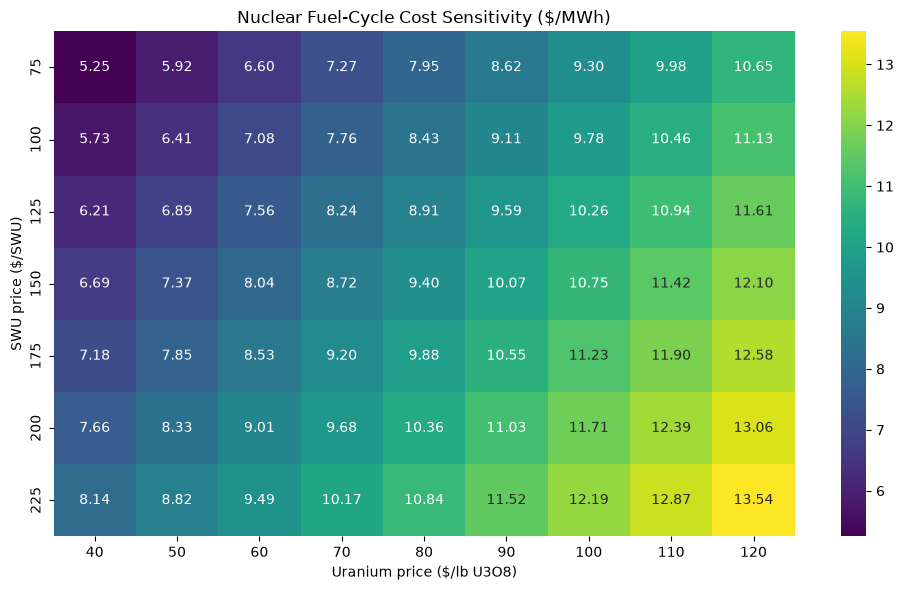

In [3]:
reactor = PWR()
uranium_prices = np.arange(40, 121, 10)
swu_prices = np.arange(75, 226, 25)

sensitivity = []
for uranium_price_lb in uranium_prices:
    for swu_price in swu_prices:
        fuel = FuelCycle(uranium_price_lb=uranium_price_lb, swu_price=swu_price)

        costs = fuel.cost(reactor.annual_fuel_requirement_kg)
        fuel_cost_mwh = costs["total"] / reactor.annual_generation_mwh

        sensitivity.append({
            "uranium_price": uranium_price_lb,
            "swu_price": swu_price,
            "fuel_cost_mwh": fuel_cost_mwh,
        })

sensitivity_df = pd.DataFrame(sensitivity)
heatmap_data = sensitivity_df.pivot(
    index="swu_price",
    columns="uranium_price",
    values="fuel_cost_mwh",
)
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="viridis")
plt.xlabel("Uranium price ($/lb U3O8)")
plt.ylabel("SWU price ($/SWU)")
plt.title("Nuclear Fuel-Cycle Cost Sensitivity ($/MWh)")
plt.tight_layout()
plt.show()

# Nuclear vs Gas

In [4]:
reactor = PWR()
fuel = FuelCycle()
gas = GasPlant()

cost = fuel.cost(reactor.annual_fuel_requirement_kg)
nuclear_cost = cost["total"] / reactor.annual_generation_mwh

gas_cost = gas.marginal_cost(gas_price_mmbtu=3.00, carbon_price_tco2=50.00)

spread = gas.nuclear_gas_spread(
    nuclear_cost_mwh=nuclear_cost,
    gas_cost_mwh=gas_cost,
)
print(f"Nuclear cost: ${nuclear_cost:.2f}/MWh")
print(f"Gas cost:     ${gas_cost:.2f}/MWh")
print(f"Spread:       ${spread:.2f}/MWh")
print()

breakeven = gas.breakeven_gas_price(
    nuclear_cost_mwh=nuclear_cost,
    carbon_price_tco2=50.0,
)
print(f"Breakeven gas price: ${breakeven:.2f}/MMBtu")

Nuclear cost: $8.72/MWh
Gas cost:     $41.50/MWh
Spread:       $32.78/MWh

Breakeven gas price: $-1.68/MMBtu


### Observations:

* our model is comparing the variable cost between nuclear and gas
* if we looked at the total cost, this would probably be different. Nuclear has a high capital cost, larger than gas

# Sensitivity Studies

## Spread vs Gas Prices

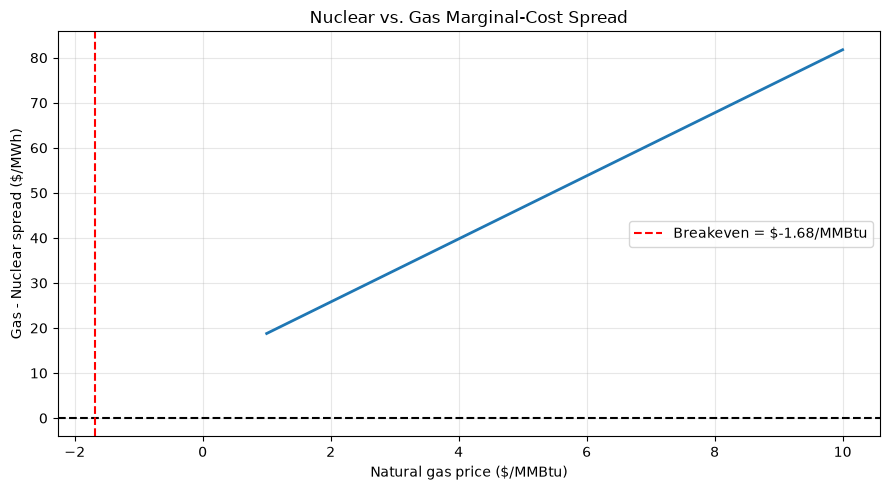

In [5]:
gas_prices = np.arange(1.0, 10.1, 0.25)

spreads = []
for gas_price in gas_prices:
    gas_cost = gas.marginal_cost(gas_price_mmbtu=gas_price, carbon_price_tco2=50.0)
    spread = gas.nuclear_gas_spread(nuclear_cost_mwh=nuclear_cost, gas_cost_mwh=gas_cost)
    spreads.append(spread)

plt.figure(figsize=(9, 5))
plt.plot(gas_prices, spreads, linewidth=2)
plt.axhline(0, color="black", linestyle="--")
plt.axvline(breakeven, color="red", linestyle="--", label=f"Breakeven = ${breakeven:.2f}/MMBtu")

plt.xlabel("Natural gas price ($/MMBtu)")
plt.ylabel("Gas - Nuclear spread ($/MWh)")
plt.title("Nuclear vs. Gas Marginal-Cost Spread")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observations:

* The blue line starts at $1/MMBtu, since that's the minimum price analyzed.
* To connect all the way to the breakeven price, I would need to study negative values.

## Spread vs Uranium Price and SWU Price

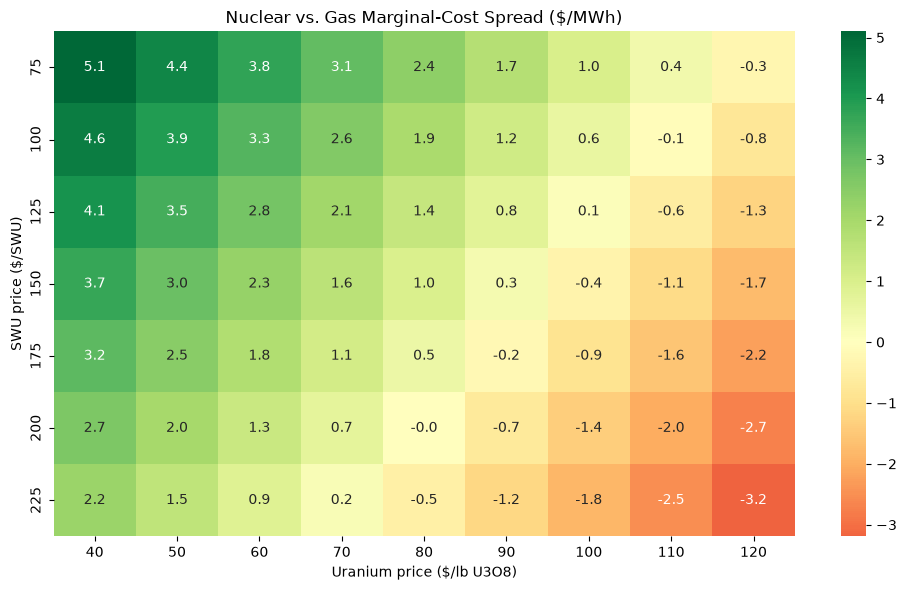

In [6]:
uranium_prices = np.arange(40, 121, 10)
swu_prices = np.arange(75, 226, 25)

spread_results = []
for uranium_price in uranium_prices:
    for swu_price in swu_prices:
        fuel = FuelCycle(uranium_price_lb=uranium_price, swu_price=swu_price)
        cost = fuel.cost(reactor.annual_fuel_requirement_kg)
        nuclear_cost = cost["total"] / reactor.annual_generation_mwh
        gas_cost = gas.marginal_cost(gas_price_mmbtu=1.0, carbon_price_tco2=1.0)
        spread = gas.nuclear_gas_spread(nuclear_cost, gas_cost)

        spread_results.append({
            "uranium_price": uranium_price,
            "swu_price": swu_price,
            "spread": spread,
        })

spread_df = pd.DataFrame(spread_results)
spread_heatmap = spread_df.pivot(
    index="swu_price",
    columns="uranium_price",
    values="spread",
)
plt.figure(figsize=(10, 6))
sns.heatmap(spread_heatmap, annot=True, fmt=".1f", cmap="RdYlGn", center=0)
plt.xlabel("Uranium price ($/lb U3O8)")
plt.ylabel("SWU price ($/SWU)")
plt.title("Nuclear vs. Gas Marginal-Cost Spread ($/MWh)")
plt.tight_layout()
plt.show()

### Observations:

* The plot above shows in green when the spread benefits nuclear (Nuclear is cheaper than Gas), and in red when it's the opposite.
* Note the numbers for gas are made up, assuming: \\$1/MMBtu and \\$1/tCO2. Otherwise, it was all green.

# Retrieve Historical Data

In [7]:
price_U3O8_df = pd.read_csv("data/UHistory.csv")
price_U3O8_df["Date"] = pd.to_datetime(price_U3O8_df["Date"], dayfirst=True)

# Convert daily U3O8 observations to monthly average
u3o8_monthly = (
    price_U3O8_df
    .assign(Month=price_U3O8_df["Date"].dt.to_period("M"))
    .groupby("Month")["U3O8"]
    .mean()
    .reset_index()
    .rename(columns={"U3O8": "uranium_price"})
)
u3o8_monthly

,Month,uranium_price
0,2007-07,111.666667
1,2007-08,96.090909
2,2007-09,81.210526
3,2007-10,77.204545
4,2007-11,92.545455
...,...,...
225,2026-04,85.986364
226,2026-05,85.420952
227,2026-06,85.585455
228,2026-07,85.525652


In [8]:
# gas price data
price_gas_df = pd.read_csv("data/Henry_Hub_Natural_Gas_Spot_Price.csv", skiprows=4)
price_gas_df["Date"] = pd.to_datetime(price_gas_df["Month"], format="%b %Y")

# Rename column
spot_price_col = "Henry Hub Natural Gas Spot Price Dollars per Million Btu"
gas_monthly = (
    price_gas_df[["Date", spot_price_col]]
        .rename(columns={spot_price_col: "gas_price"})
)

# Convert to monthly period
gas_monthly["Month"] = gas_monthly["Date"].dt.to_period("M")
gas_monthly

,Date,gas_price,Month
0,2026-07-01,2.89,2026-07
1,2026-06-01,3.15,2026-06
2,2026-05-01,2.94,2026-05
3,2026-04-01,2.77,2026-04
4,2026-03-01,3.04,2026-03
...,...,...,...
350,1997-05-01,2.25,1997-05
351,1997-04-01,2.03,1997-04
352,1997-03-01,1.89,1997-03
353,1997-02-01,2.15,1997-02


In [9]:
# merge datasets
market_df = pd.merge(
    gas_monthly[["Month", "gas_price"]],
    u3o8_monthly[["Month", "uranium_price"]],
    on="Month",
    how="inner",
)

# convert Period back to timestamp
market_df["Date"] = market_df["Month"].dt.to_timestamp()

market_df = (
    market_df[["Date", "uranium_price", "gas_price"]]
    .sort_values("Date")
    .reset_index(drop=True)
)
market_df

,Date,uranium_price,gas_price
0,2007-07-01,111.666667,6.22
1,2007-08-01,96.090909,6.22
2,2007-09-01,81.210526,6.08
3,2007-10-01,77.204545,6.74
4,2007-11-01,92.545455,7.10
...,...,...,...
224,2026-03-01,85.231818,3.04
225,2026-04-01,85.986364,2.77
226,2026-05-01,85.420952,2.94
227,2026-06-01,85.585455,3.15


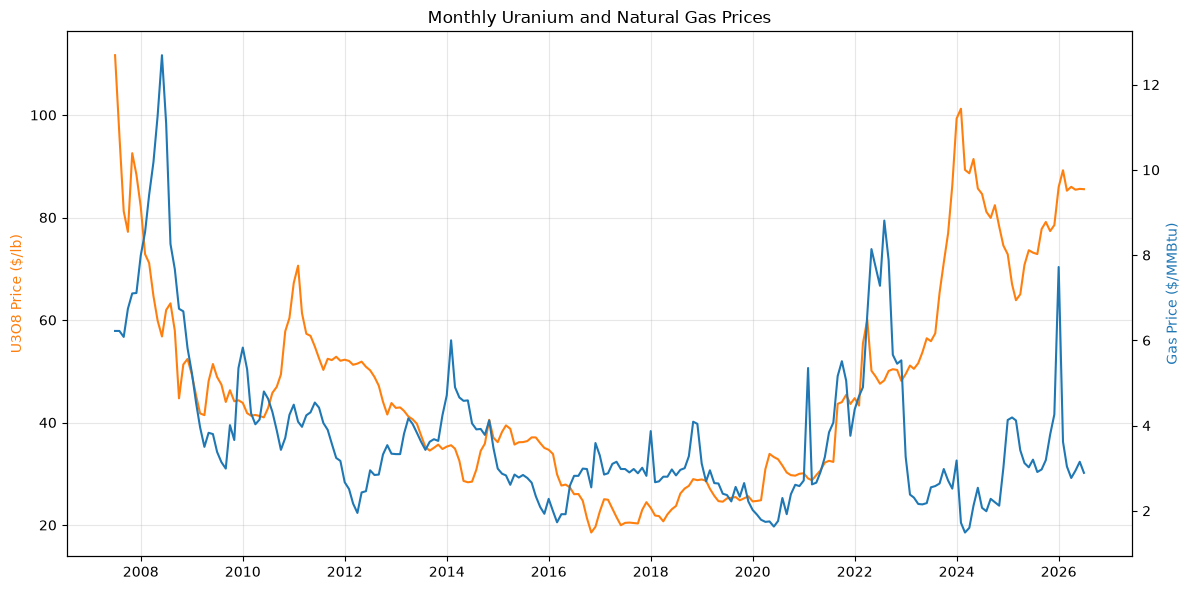

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(market_df["Date"], market_df["uranium_price"], color="tab:orange")
ax1.set_ylabel("U3O8 Price ($/lb)", color="tab:orange")

ax2 = ax1.twinx()
ax2.plot(market_df["Date"], market_df["gas_price"], color="tab:blue")
ax2.set_ylabel("Gas Price ($/MMBtu)", color="tab:blue")

ax1.set_title("Monthly Uranium and Natural Gas Prices")
ax1.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Ingest market data into our model

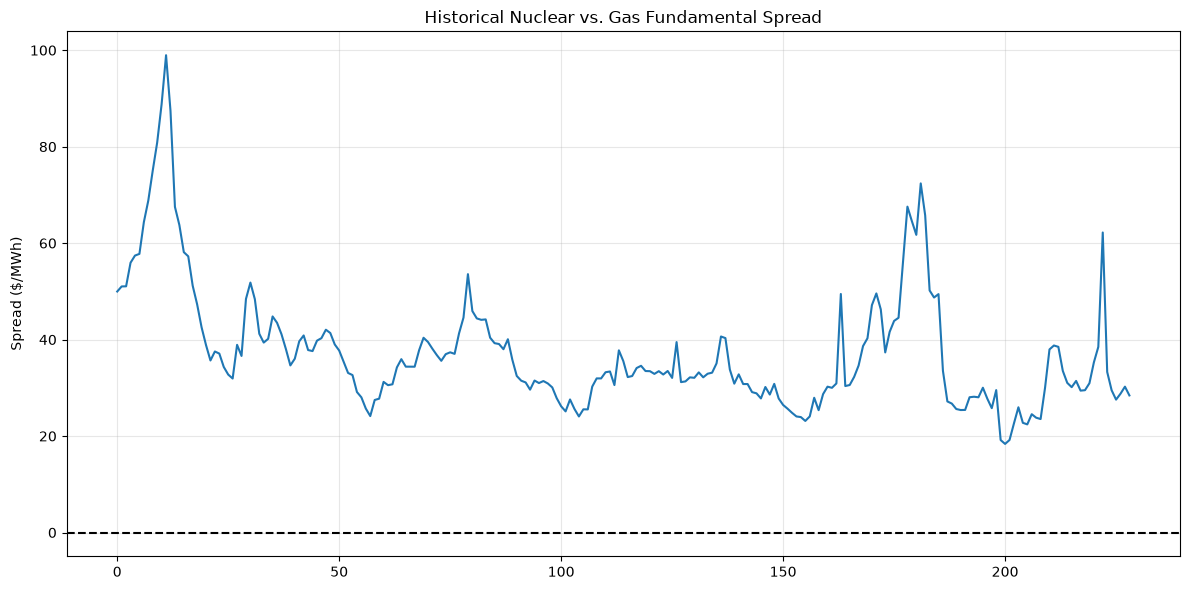

In [34]:
reactor = PWR()
gas = GasPlant()

def calculate_nuclear_cost(uranium_price: float) -> float:
    fuel = FuelCycle(uranium_price_lb=uranium_price, swu_price=100.0)
    cost = fuel.cost(reactor.annual_fuel_requirement_kg)
    return cost["total"] / reactor.annual_generation_mwh

def calculate_gas_cost(gas_price: float, carbon_price: float = 40.0) -> float:
    return gas.marginal_cost(gas_price_mmbtu=gas_price, carbon_price_tco2=carbon_price)

market_df["nuclear_cost"] = market_df["uranium_price"].apply(calculate_nuclear_cost)
market_df["gas_cost"] = market_df["gas_price"].apply(calculate_gas_cost)
market_df["spread"] = market_df["gas_cost"] - market_df["nuclear_cost"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(market_df.index, market_df["spread"], label="Gas - Nuclear Spread")
ax.axhline(0, color="black", linestyle="--")
ax.set_ylabel("Spread ($/MWh)")
ax.set_title("Historical Nuclear vs. Gas Fundamental Spread")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Add historical data for power

In [5]:
# NO NEED TO RE-RUN THIS ONCE YOU ALREADY HAVE
# pjm_lmp_da_allegheny_2020_2025.csv
EIA_URL = "https://www.eia.gov/electricity/wholesalemarkets/csv/pjm_lmp_da_hr_zones_{year}.csv"

dfs = []
for year in range(2020, 2026, 1):
    url = EIA_URL.format(year=year)
    print(f"Reading {url} ...")
    resp = requests.get(url, timeout=60)
    resp.raise_for_status()
    raw = pd.read_csv(io.BytesIO(resp.content), skiprows=3)
    
    utc_col = [c for c in raw.columns if "UTC" in c][0]
    lmp_col = [c for c in raw.columns if "Allegheny Power System LMP" == c][0]
    df = raw[[utc_col, lmp_col]].rename(columns={utc_col: "utc_timestamp", lmp_col: "lmp_usd_mwh"})
    dfs.append(df)

# Combine all years
pjm_df = pd.concat(dfs, ignore_index=True)
# Clean timestamp
pjm_df["utc_timestamp"] = pd.to_datetime(pjm_df["utc_timestamp"], utc=True)
# Make sure LMP is numeric
pjm_df["lmp_usd_mwh"] = pd.to_numeric(pjm_df["lmp_usd_mwh"], errors="coerce")
# Remove invalid observations
pjm_df = (
    pjm_df
    .dropna(subset=["utc_timestamp", "lmp_usd_mwh"])
    .sort_values("utc_timestamp")
    .reset_index(drop=True)
)
# Save
pjm_df.to_csv("data/pjm_lmp_da_allegheny_2020_2025.csv", index=False)

print(pjm_df.head())
print(f"\nObservations: {len(pjm_df):,}")
print(f"Saved to: data/pjm_lmp_da_allegheny_2020_2025.csv")

Reading https://www.eia.gov/electricity/wholesalemarkets/csv/pjm_lmp_da_hr_zones_2020.csv ...
Reading https://www.eia.gov/electricity/wholesalemarkets/csv/pjm_lmp_da_hr_zones_2021.csv ...
Reading https://www.eia.gov/electricity/wholesalemarkets/csv/pjm_lmp_da_hr_zones_2022.csv ...
Reading https://www.eia.gov/electricity/wholesalemarkets/csv/pjm_lmp_da_hr_zones_2023.csv ...
Reading https://www.eia.gov/electricity/wholesalemarkets/csv/pjm_lmp_da_hr_zones_2024.csv ...
Reading https://www.eia.gov/electricity/wholesalemarkets/csv/pjm_lmp_da_hr_zones_2025.csv ...
              utc_timestamp  lmp_usd_mwh
0 2020-09-05 05:00:00+00:00    15.326068
1 2020-09-05 06:00:00+00:00    14.671615
2 2020-09-05 07:00:00+00:00    14.007430
3 2020-09-05 08:00:00+00:00    13.131775
4 2020-09-05 09:00:00+00:00    12.309257

Observations: 40,344
Saved to: data/pjm_lmp_da_allegheny_2020_2025.csv


In [11]:
power_df = pd.read_csv("data/pjm_lmp_da_allegheny_2020_2025.csv")
power_df

,utc_timestamp,lmp_usd_mwh
0,2020-09-05 05:00:00+00:00,15.326068
1,2020-09-05 06:00:00+00:00,14.671615
2,2020-09-05 07:00:00+00:00,14.007430
3,2020-09-05 08:00:00+00:00,13.131775
4,2020-09-05 09:00:00+00:00,12.309257
...,...,...
40339,2025-06-25 00:00:00+00:00,440.173988
40340,2025-06-25 01:00:00+00:00,287.791063
40341,2025-06-25 02:00:00+00:00,160.177730
40342,2025-06-25 03:00:00+00:00,89.685946


In [35]:
market_df.head()

,Date,uranium_price,gas_price,nuclear_cost,gas_cost,spread
0,2007-07-01,111.666667,6.22,10.570146,60.54,49.969854
1,2007-08-01,96.090909,6.22,9.518183,60.54,51.021817
2,2007-09-01,81.210526,6.08,8.513184,59.56,51.046816
3,2007-10-01,77.204545,6.74,8.242626,64.18,55.937374
4,2007-11-01,92.545455,7.10,9.278728,66.70,57.421272


In [13]:
# assumption (this doesn't really matter since we will look at the monthly averages)
_TZ = "America/New_York"

# convert dates with time stamps to months
power_monthly = power_df.assign(
    Date=(
        pd.to_datetime(power_df["utc_timestamp"])
        .dt.tz_convert(_TZ)
        .dt.to_period("M")
        .dt.to_timestamp()
    )
)

# group by 'Date' which is each month (use the monthly average value)
power_monthly = power_monthly.groupby("Date", as_index=False).agg(
    power_price=("lmp_usd_mwh", "mean")
    )

power_monthly.head()

/var/folders/kg/c7cyx8fj53z9ky_g8hn8pbvm0000gq/T/ipykernel_10557/463821481.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,Date,power_price
0,2020-09-01,19.592610
1,2020-10-01,21.676409
2,2020-11-01,21.633355
3,2020-12-01,26.779866
4,2021-01-01,26.222472


In [36]:
df = market_df.merge(power_monthly, on="Date", how="inner")
df.set_index("Date", inplace=True)
df.head()

,uranium_price,gas_price,nuclear_cost,gas_cost,spread,power_price
Date,,,,,,
2020-09-01,30.250000,1.92,5.071385,30.44,25.368615,19.592610
2020-10-01,29.730455,2.39,5.036296,33.73,28.693704,21.676409
2020-11-01,29.634762,2.61,5.029833,35.27,30.240167,21.633355
2020-12-01,30.000000,2.58,5.054501,35.06,30.005499,26.779866
2021-01-01,30.102857,2.71,5.061447,35.97,30.908553,26.222472


## Some EDA

In [37]:
# Basic info
print(df.info())
print("\nMissing values:")
print(df.isna().sum())

print("\nSummary statistics:")
print(df.describe())

<class 'pandas.DataFrame'>
DatetimeIndex: 57 entries, 2020-09-01 to 2025-06-01
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   uranium_price  57 non-null     float64
 1   gas_price      57 non-null     float64
 2   nuclear_cost   57 non-null     float64
 3   gas_cost       57 non-null     float64
 4   spread         57 non-null     float64
 5   power_price    57 non-null     float64
dtypes: float64(6)
memory usage: 3.1 KB
None

Missing values:
uranium_price    0
gas_price        0
nuclear_cost     0
gas_cost         0
spread           0
power_price      0
dtype: int64

Summary statistics:
       uranium_price  gas_price  nuclear_cost   gas_cost     spread  \
count      57.000000  57.000000     57.000000  57.000000  57.000000   
mean       57.134497   3.677018      6.887124  42.739123  35.851998   
std        20.569516   1.807829      1.389235  12.654804  13.164782   
min        28.735652   1.490000      4.9691

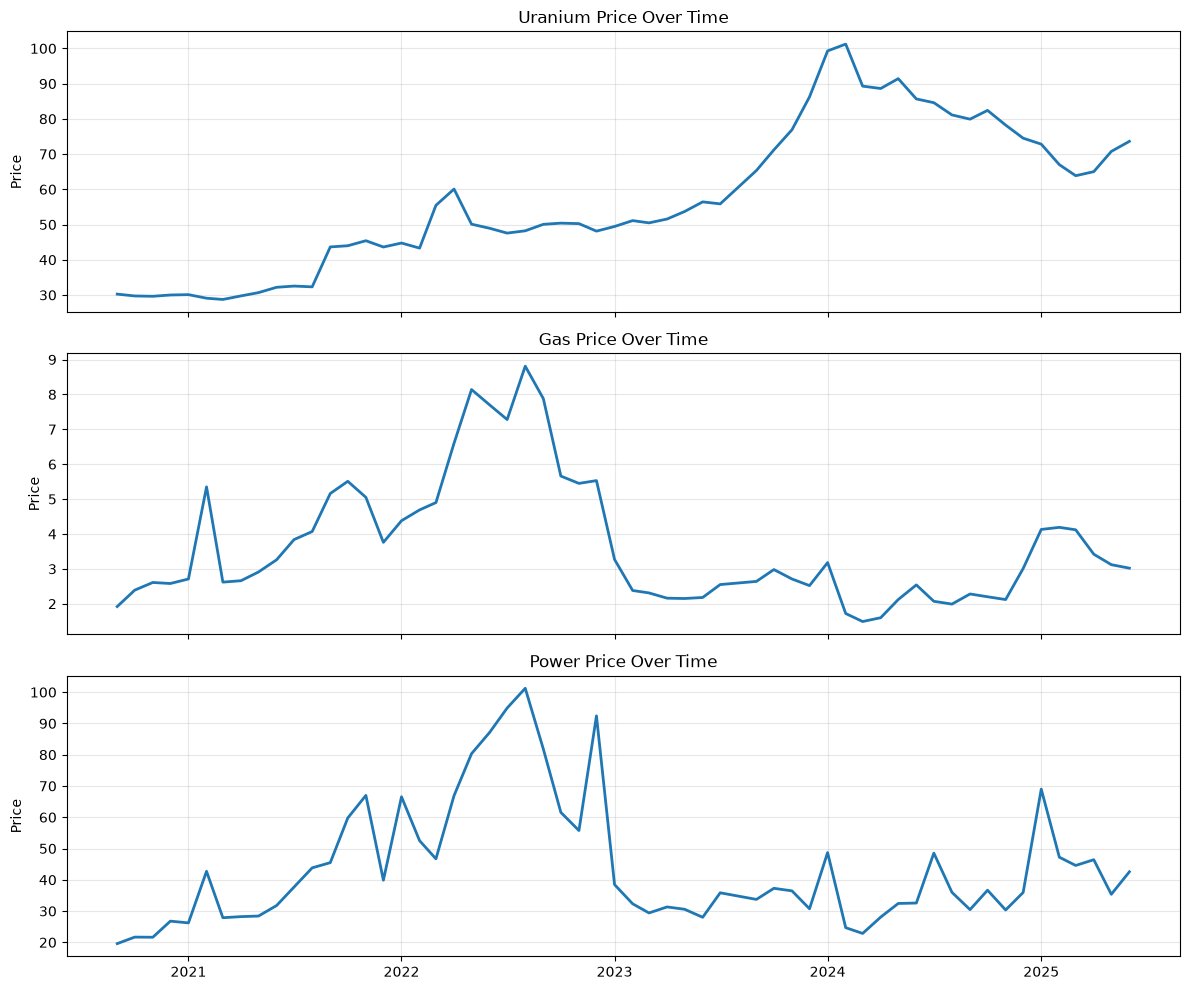

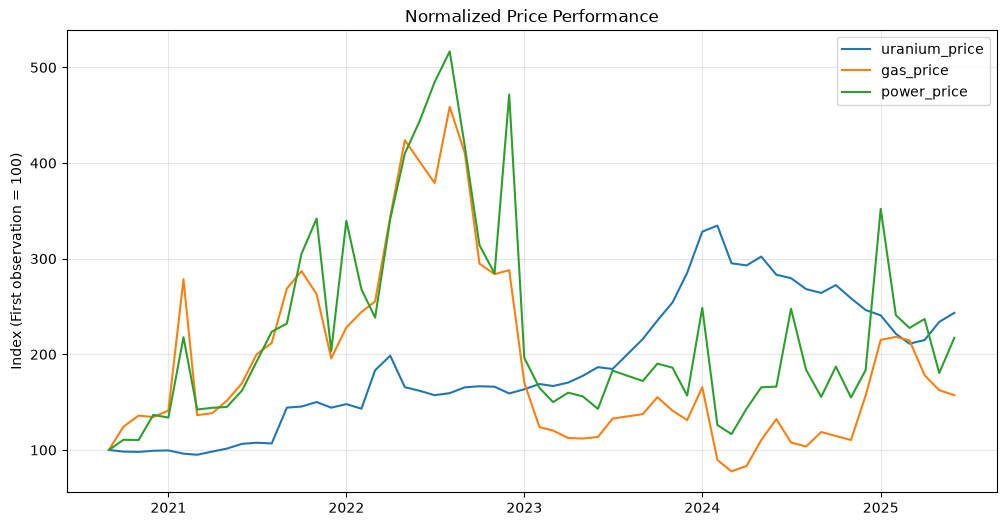

In [31]:
# Price Levels
price_cols = ['uranium_price', 'gas_price', 'power_price']
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, col in zip(axes, price_cols):
    ax.plot(df.index, df[col], linewidth=2)
    ax.set_title(f"{col.replace('_', ' ').title()} Over Time")
    ax.set_ylabel("Price")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Normalize Prices
normalized = df.div(df.iloc[0]) * 100
plt.figure(figsize=(12, 6))
for col in price_cols:
    plt.plot(df.index, normalized[col], label=col)
plt.title("Normalized Price Performance")
plt.ylabel("Index (First observation = 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Observations:

* Electricity prices are much more exposed to marginal gas generation costs than to uranium prices

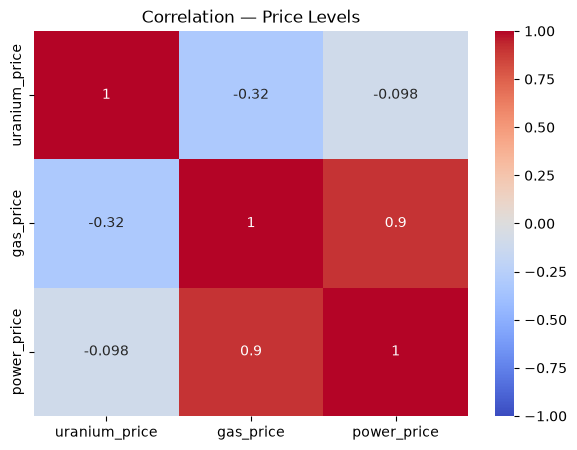

In [32]:
plt.figure(figsize=(7, 5))
sns.heatmap(
    df[price_cols].corr(),
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)
plt.title("Correlation — Price Levels")
plt.show()

### Observations:

* Confirmed. Strong correlation between `gas_price` and `power_price`

# Statistical Research

Now, if the gas prices and power are correlated, let see if the spread moves with electricity prices.

               spread  power_price
spread       1.000000     0.877902
power_price  0.877902     1.000000


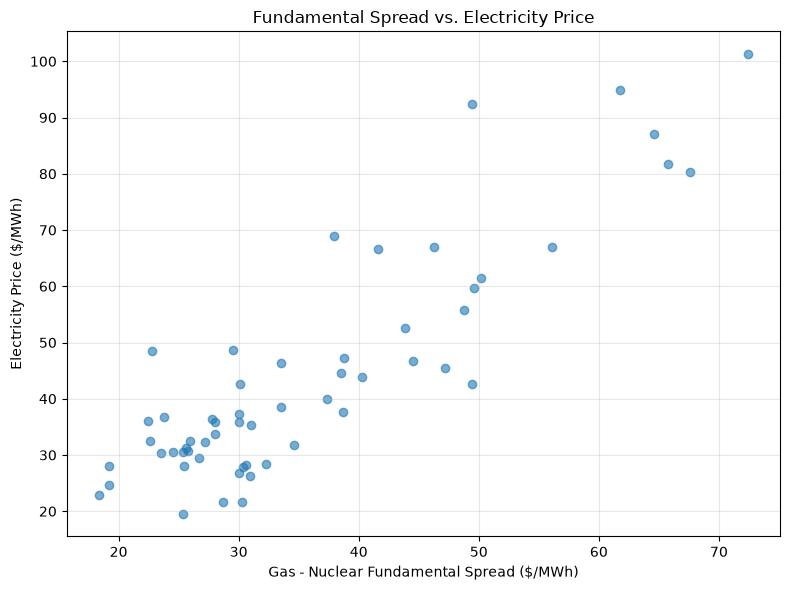

In [38]:
correlation = df[["spread", "power_price"]].corr()
print(correlation)

plt.figure(figsize=(8, 6))
plt.scatter(df["spread"], df["power_price"], alpha=0.6)
plt.xlabel("Gas - Nuclear Fundamental Spread ($/MWh)")
plt.ylabel("Electricity Price ($/MWh)")
plt.title("Fundamental Spread vs. Electricity Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Observations:

The spread and electricity prices are strongly correlated (not necessarily causation).
Changes in the spread may be an important driver of electricity price movements.

This shows: $Corr(S_t, P_t)=0.878$

## Statistical research:

Checks if:
$$
\Delta P_t = \alpha + \beta \Delta S_t + \epsilon_t
$$
where $\Delta P_t = P_t - P_{t-1}$ and $\Delta S_t = S_t - S_{t-1}$

This is checking whether changes in the fundamental spread are associated with contemporaneous changes in power prices.

In [85]:
# this is checking the contemporaneous correlation
# Do changes in the spread predict changes in power prices?
df["spread_change"] = df["spread"].diff()
df["power_change"] = df["power_price"].diff()

regression_df = df.dropna(subset=["spread_change", "power_change"])
X = sm.add_constant(regression_df["spread_change"])
y = regression_df["power_change"]
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           power_change   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.426
Method:                 Least Squares   F-statistic:                     41.86
Date:                Sun, 09 Aug 2026   Prob (F-statistic):           2.98e-08
Time:                        14:22:14   Log-Likelihood:                -213.12
No. Observations:                  56   AIC:                             430.2
Df Residuals:                      54   BIC:                             434.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.2805      1.481      0.189

$$
\Delta P_t = 0.2805 + 1.5229 \Delta S_t
$$
* R^2: 0.437, this is not very high, but it's not low either
* F-statistic: 41.86, it means that the variance explained by the model is 42 times larger than the unexplained variance (the random error or noise). An F-statistic this high is highly statistically significant.
* p-value of the F-statistic is very small (<0.001) meaning that the regression model is statistically significant
* coef: 1.5229. A \\$1/MWh increase in the monthly gas-vs-nuclear spread is associated with approximately a $1.52/MWh increase in the monthly PJM power price change.
* coef std error: 0.235
* t-statistic: 6.47. The estimated coefficient is many standard errors away from zero (~(1.5229-0)/0.235))
* P>|t|, p-value of a two-tailed t-test. It tests the null hypothesis that a regression coefficient is equal to zero (no effect). The p-value coef is very small (<0.001). So there is a strong statistical evidence that the coefficient is different from zero
* `spread_change` has a positive and statistically significant association with `power_change`.
* The 95% CI for the coef is [1.051 - 1.995]
* const = 0.2805
* the p-value is 0.850, meaning that there isn't evidence that the intercept is different from 0

Also, this shows: $Corr(\Delta S_t, \Delta P_t)=r=sign(\beta)\sqrt{R^2}=0.66$

r: Pearson correlation

## Further analyses

So far this has answered the question. Are these variables simply moving together?
Now we need to answer, can we actually predict power prices?

Something else to consider (maybe in the future):
* The spread is: $S_t = MC_{gas, t} - MC_{nuclear, t}$
* $MC_{gas, t} = Gas_t \cdot HR + CarbonCost$
* So, the spread contains the gas price.
* Electricity prices in PJM are heavily influenced by natural gas.
* Some of the 0.66 correlation could be: $Gas_t --> Spread_t$ or $Gas_t --> Prices_t$
* Rather than the nuclear-vs-gas model explaining power prices
* (this is explained by some of the plots in EDA, that gas and power prices are strongly correlated)

Other studies:
* Compare power price to gas: $\Delta P_t = \alpha + \beta_1 \Delta Gas_t + \epsilon_t$
* Compare power prices to gas and uranium prices: $\Delta P_t = \alpha + \beta_1 \Delta Gas_t + \beta_2 \Delta Uranium_t + \epsilon_t$
* If the spread is unusually high, gas is relatively expensive compared with nuclear. Does that tells us something where PJM power prices go next month?
$$
\Delta P_{t+1} = \alpha + \beta S_t + \epsilon_{t+1}
$$
* Does a change in the fundamental spread predict next month's power-price change? For example, $\Delta S_t = +10$ means that gas-vs-nuclear economics just became \\$10/MWh more favorable to nuclear. Does that shock propagate into power prices next month? 
$$
\Delta P_{t+1} = \alpha + \beta \Delta S_t + \epsilon_{t+1}
$$


# Trading

The results up to this point are research signals, not evidence of profitability.
This strategy uses high/low spread values to decide whether to be long, short, or flat on power for the following month.
The strategy corresponds to a one-month-ahead strategy based on the spread's z-score:
$$
Z_t = \frac{S_t - \mu_t}{\sigma_t}
$$

$$
Signal_t = \begin{cases}
+ 1 \quad \quad Z_t > 1 \\
0 \quad -1 \le Z_t \le 1 \\
- 1 \quad Z_t < -1
\end{cases}
$$
* z-score > +1 → signal = +1: nuclear is cheaper than gas, take a long position (buy).
* z-score < −1 → signal = −1: gas is cheaper than nuclear, take a short position (sell).
* −1 ≤ z-score ≤ +1 → signal = 0: stay out of the market.?

The position is applied to the next month's power-price change, avoiding look-ahead bias.
+1/−1 represents one unit of exposure (conceptually 1 MWh in this simplified model).

P&L is:
$$
P\&L = Signal_t \cdot (P_{t+1} - P_t)
$$

Example: for a long position (signal = +1) and power rises from \\$50 to \\$55, the P&L is: 1×(55−50)=+\\$5. <br />
For a short position (signal = -1), the same move gives −\\$5. <br />
The cumulative strategy P&L is compared with buy-and-hold, which is always long one unit of power.

In [39]:
df["spread_z"] = (
    (df["spread"] - df["spread"].rolling(12).mean())
    / df["spread"].rolling(12).std()
)

df["signal"] = 0
df.loc[df["spread_z"] > 1, "signal"] = 1
df.loc[df["spread_z"] < -1, "signal"] = -1
# the signal available at month t can only be applied to
# the subsequent month's return/change
# df["signal"] = df["signal"].shift(1)
# actually no need to do this, since we are using power_change_next
# which is computed as P_{t+1} - P_{t}, this is already shifted

<Axes: xlabel='Date'>

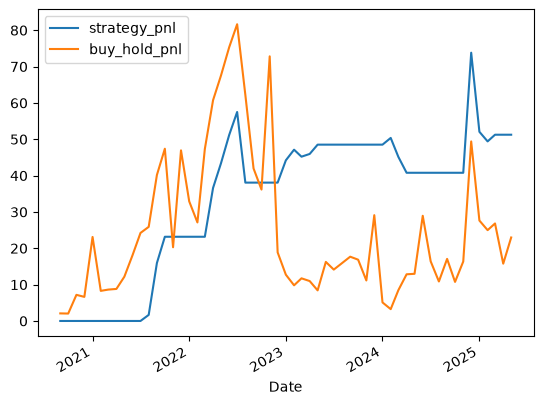

In [41]:
# one month ahead return
df["power_change_next"] = df["power_price"].shift(-1) - df["power_price"]

df["strategy_pnl"] = df["signal"] * df["power_change_next"]
df["buy_hold_pnl"] = df["power_change_next"]
df[["strategy_pnl", "buy_hold_pnl"]].cumsum().plot()

The "buy and hold" is not really holding, it is more like 'long power price change'.
We are accumulating $P_{t+1} - P_t$. So:
$$
\sum_t \left( P_{t+1} - P_t \right) = P_T - P_0
$$
which is the change in the power price over the sample time.

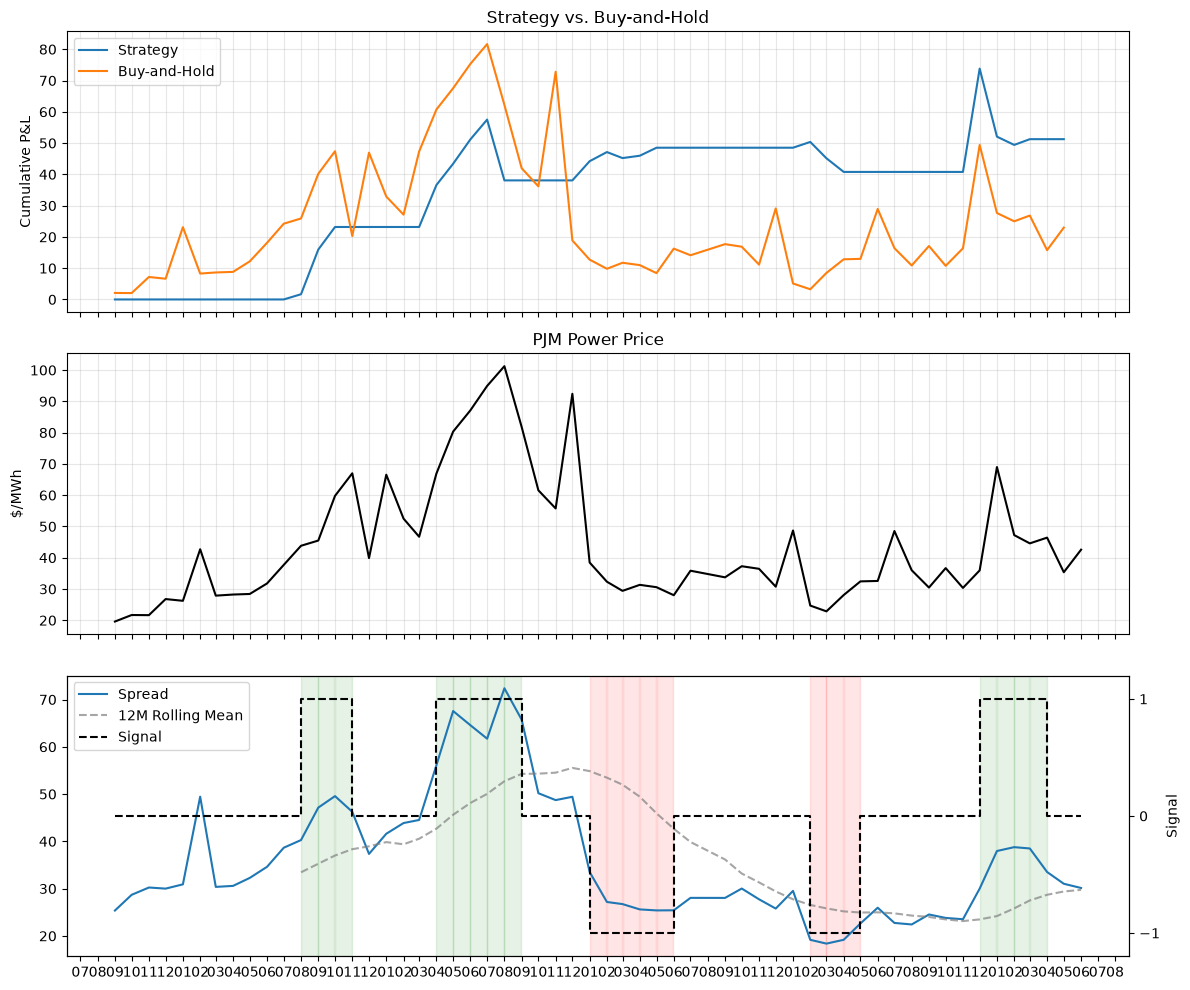

In [42]:
import matplotlib.dates as mdates

df.reset_index(names=["Date"], inplace=True)
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# P&L
axes[0].plot(df["Date"], df["strategy_pnl"].cumsum(), label="Strategy")
axes[0].plot(df["Date"], df["buy_hold_pnl"].cumsum(), label="Buy-and-Hold")
axes[0].set_title("Strategy vs. Buy-and-Hold")
axes[0].set_ylabel("Cumulative P&L")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Power
axes[1].plot(df["Date"], df["power_price"], color="black")
axes[1].set_title("PJM Power Price")
axes[1].set_ylabel("$/MWh")
axes[1].grid(alpha=0.3)

# Spread
axes[2].plot(df["Date"], df["spread"], color="tab:blue", label="Spread")
axes[2].plot(df["Date"], df["spread"].rolling(12).mean(), color="gray", linestyle="--", alpha=0.7, label="12M Rolling Mean")

ax_signal = axes[2].twinx()
ax_signal.plot(df["Date"], df["signal"], color="black", linestyle="--", drawstyle="steps-post", label="Signal")
ax_signal.set_ylabel("Signal")
ax_signal.set_ylim(-1.2, 1.2)
ax_signal.set_yticks([-1, 0, 1])

lines1, labels1 = axes[2].get_legend_handles_labels()
lines2, labels2 = ax_signal.get_legend_handles_labels()
axes[2].legend(lines1 + lines2, labels1 + labels2, loc="upper left")

# Highlight active positions
for _, row in df.iterrows():
    if row["signal"] == 1:
        axes[2].axvspan(row["Date"], row["Date"] + pd.offsets.MonthEnd(1), color="green", alpha=0.10)
    elif row["signal"] == -1:
        axes[2].axvspan(row["Date"], row["Date"] + pd.offsets.MonthEnd(1), color="red", alpha=0.10)

# X-axis: month numbers
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%m"))
axes[2].tick_params(axis="x", labelbottom=True)

plt.tight_layout()
plt.show()

In [44]:
strategy = df["strategy_pnl"].dropna()
print(f"Total P&L: {strategy.sum():.3f}")
print(f"Mean monthly P&L: {strategy.mean():.3f}")
print(f"Std monthly P&L: {strategy.std():.3f}")
# only accounts when strategy is > 0, counting flat as a failure
print(f"Hit rate: {(strategy > 0).mean():3f}") 
# this accounts when actually holding a position
active = df["signal"] != 0
hit_rate = (df.loc[active, "strategy_pnl"] > 0).mean()
print(f"Active hit rate: {hit_rate:.3f}")
print()

sharpe = strategy.mean() / strategy.std() * np.sqrt(12)
print(f"Annualized Sharpe: {sharpe:.3f}")
print()

print(f'Number of trades: {(df["signal"].diff() != 0).sum()}')
print(f'Time in market: {(df["signal"] != 0).mean():.3f}')
print()

print(f'Winning months: {(df.loc[active, "strategy_pnl"] > 0).sum():.3f}')
print(f'Losing months: {(df.loc[active, "strategy_pnl"] < 0).sum():.3f}')

Total P&L: 51.252
Mean monthly P&L: 0.915
Std monthly P&L: 6.875
Hit rate: 0.250000
Active hit rate: 0.700

Annualized Sharpe: 0.461

Number of trades: 11
Time in market: 0.351

Winning months: 14.000
Losing months: 6.000


Max drawdown: -24.409


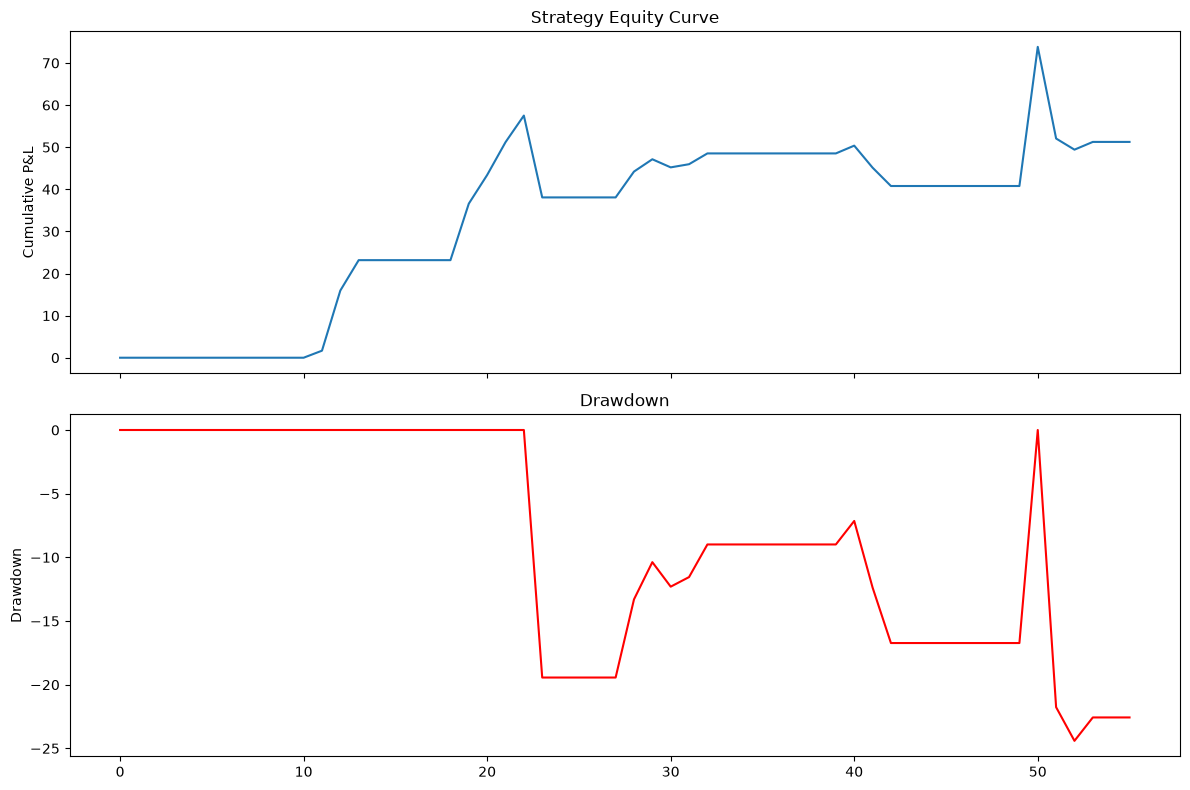

In [45]:
equity = df["strategy_pnl"].cumsum()
drawdown = equity - equity.cummax()
print(f"Max drawdown: {drawdown.min():.3f}")

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
equity.plot(ax=ax[0], title="Strategy Equity Curve")
ax[0].set_ylabel("Cumulative P&L")
drawdown.plot(ax=ax[1], color="red", title="Drawdown")
ax[1].set_ylabel("Drawdown")
plt.tight_layout()

### Conclusion

* Strategy outperforms buy-and-hold over much of the period.
* Max drawdown of 24% is not terrible.
* These studes are just academic.
* Of course I wouldn't trade on it unless a lot more back testing and statistical research is done.